In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display, HTML

# Segunda parte: Análisis de la Calidad de la Leche mediante Regresión Logistica

## 1. Preprocesamiento de Datos

### Carga y exploración inicial del dataset.

In [2]:
df_milk = pd.read_csv("datasets/milknew.csv")

### Identificación y tratamiento de valores faltantes o atípicos.

In [3]:
df_milk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1059 entries, 0 to 1058
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pH          1059 non-null   float64
 1   Temprature  1059 non-null   int64  
 2   Taste       1059 non-null   int64  
 3   Odor        1059 non-null   int64  
 4   Fat         1059 non-null   int64  
 5   Turbidity   1059 non-null   int64  
 6   Colour      1059 non-null   int64  
 7   Grade       1059 non-null   object 
dtypes: float64(1), int64(6), object(1)
memory usage: 66.3+ KB


En este caso, se puede observar que no hay valores faltantes dentro del DataFrame proporcionado. En cuanto a los valores atípicos, se decidió dejar como tratamiento el 'Escalado de características' solicitado en el ultimo requerimiento de este paso 1; esto debido a que los valores atipicos estan dentro del rango posible (como en el caso del PH) o son muy pequeños en cantidad a comparación de la cantidad de datos proporcionados en el DataFrame; en este orden de ideas, con el 'Escalado' mitigamos el impacto numérico que estos puedan tener en la data.

### Codificación de la variable objetivo

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_milk["Grade_encoded"] = le.fit_transform(df_milk["Grade"])

In [5]:
codificacion = dict(zip(le.classes_, le.transform(le.classes_)))
print(codificacion)

{'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}


In [6]:
le.inverse_transform([0, 1, 2])

array(['high', 'low', 'medium'], dtype=object)

### Escalado de características númericas (ph y Temperatura)

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_milk[["pH_escalado", "Temprature_escalado"]] = scaler.fit_transform(df_milk[["pH", "Temprature"]])

#### Variables
* pH → Numerica
* Temprature → Numerica
* Taste → Valores 1 o 0
* Odor → Valores 1 o 0
* Fat → Valores 1 o 0
* Turbidity → 1 o 0
* Colour → Numerica

## 2. Análisis Estadístico Descriptivo.

### Cálculo de estadísticas descriptivas

In [8]:
df_milk.describe(include='number',percentiles=[.1, .25, .5, .75, .9, .95, .99]).T

,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
pH,1059.0,6.630123e+00,1.399679,3.000000,4.500000,6.500000,6.700000,6.800000,8.600000,9.000000,9.500000,9.500000
Temprature,1059.0,4.422663e+01,10.098364,34.000000,36.000000,38.000000,41.000000,45.000000,55.000000,66.000000,90.000000,90.000000
Taste,1059.0,5.467422e-01,0.498046,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Odor,1059.0,4.324835e-01,0.495655,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Fat,1059.0,6.713881e-01,0.469930,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Turbidity,1059.0,4.910293e-01,0.500156,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Colour,1059.0,2.518404e+02,4.307424,240.000000,245.000000,250.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000
Grade_encoded,1059.0,1.111426e+00,0.763568,0.000000,0.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000
pH_escalado,1059.0,3.170269e-16,1.000472,-2.594765,-1.522584,-0.093010,0.049947,0.121426,1.408043,1.693958,2.051351,2.051351
Temprature_escalado,1059.0,1.409008e-16,1.000472,-1.013180,-0.815035,-0.616889,-0.319671,0.076620,1.067347,2.157147,4.534893,4.534893


La celda siguiente es la preparación del Describe del DataFrame para ser agregado al documento de LateX

In [9]:
desc = df_milk.describe(include='number', percentiles=[.1, .25, .5, .75, .9, .95]).T


desc.index = desc.index.str.replace('_', r'\_')


desc.columns = [
    'count', 'mean', 'std', 'min',
    '10\%', '25\%', '50\%', '75\%', '90\%', '95\%',
    'max'
]


desc['count'] = desc['count'].astype(int)

latex_table = desc.to_latex(float_format="%.1f")


import re
latex_table = re.search(r'(\\begin\{tabular\}.*\\end\{tabular\})', latex_table, re.DOTALL).group(1)

with open("tables/descriptive_stats.tex", "w") as f:
    f.write(latex_table)

<>:9: SyntaxWarning: invalid escape sequence '\%'
<>:9: SyntaxWarning: invalid escape sequence '\%'
<>:9: SyntaxWarning: invalid escape sequence '\%'
<>:9: SyntaxWarning: invalid escape sequence '\%'
<>:9: SyntaxWarning: invalid escape sequence '\%'
<>:9: SyntaxWarning: invalid escape sequence '\%'
<>:9: SyntaxWarning: invalid escape sequence '\%'
<>:9: SyntaxWarning: invalid escape sequence '\%'
<>:9: SyntaxWarning: invalid escape sequence '\%'
<>:9: SyntaxWarning: invalid escape sequence '\%'
<>:9: SyntaxWarning: invalid escape sequence '\%'
<>:9: SyntaxWarning: invalid escape sequence '\%'
C:\Users\kimac\AppData\Local\Temp\ipykernel_10880\320868569.py:9: SyntaxWarning: invalid escape sequence '\%'
  '10\%', '25\%', '50\%', '75\%', '90\%', '95\%',
C:\Users\kimac\AppData\Local\Temp\ipykernel_10880\320868569.py:9: SyntaxWarning: invalid escape sequence '\%'
  '10\%', '25\%', '50\%', '75\%', '90\%', '95\%',
C:\Users\kimac\AppData\Local\Temp\ipykernel_10880\320868569.py:9: SyntaxWarning:

### Visualización mediante histogramas y diagramas de caja.

In [10]:
columns = ["pH", "Temprature", "Taste", "Odor", "Fat ", "Turbidity", "Colour", "pH_escalado", "Temprature_escalado"]

In [11]:
for col in columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df_milk, x=col, kde=True, bins=30)
    plt.title(f'Distribución de {col}', fontsize=14, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequencia', fontsize=12)
    plt.tight_layout()
    plt.savefig(f"images/histogramas/{col.strip()}.png", dpi=150, bbox_inches='tight')
    plt.close()

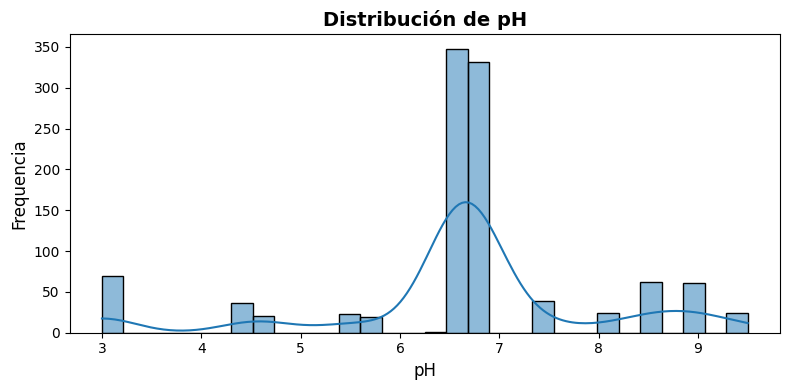

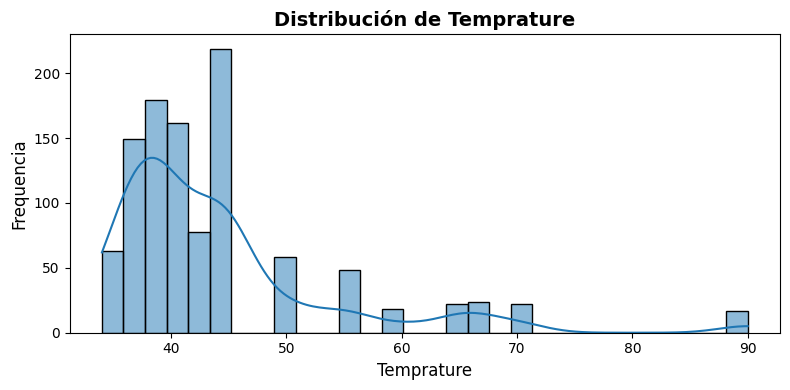

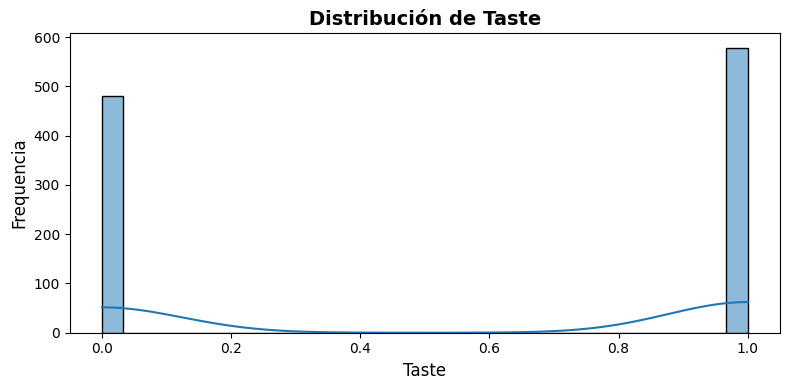

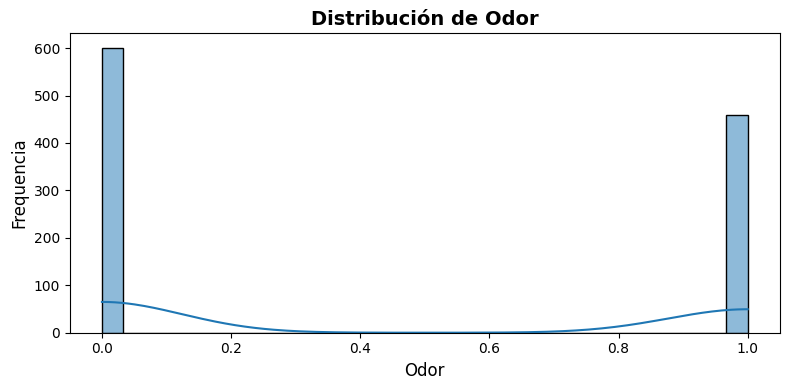

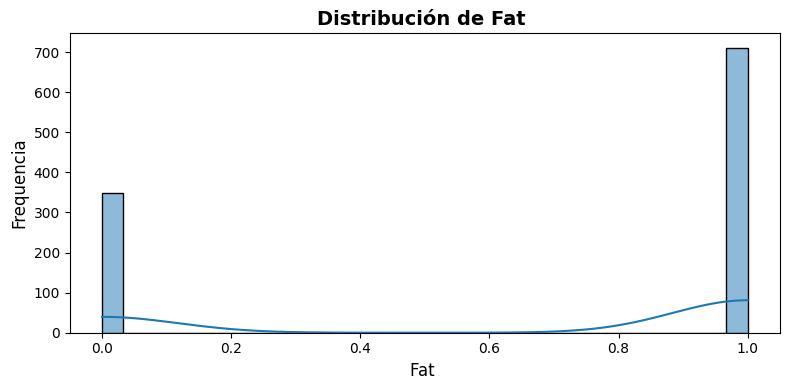

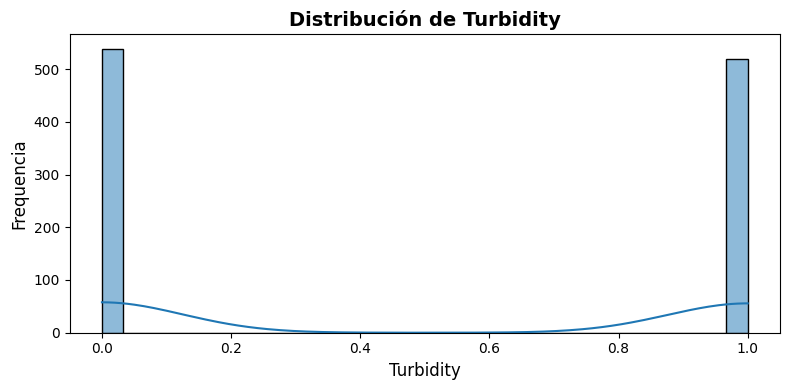

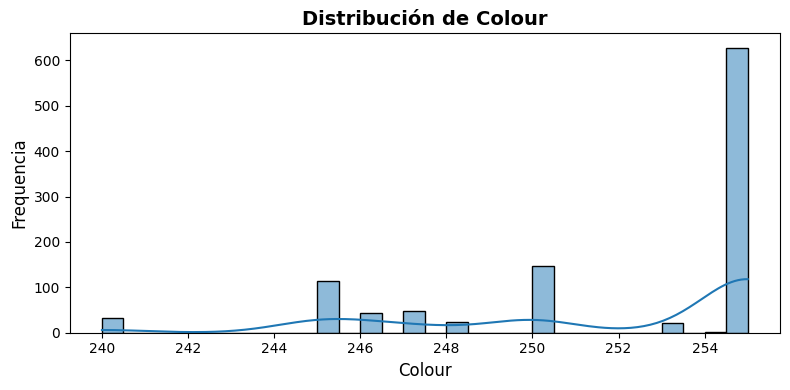

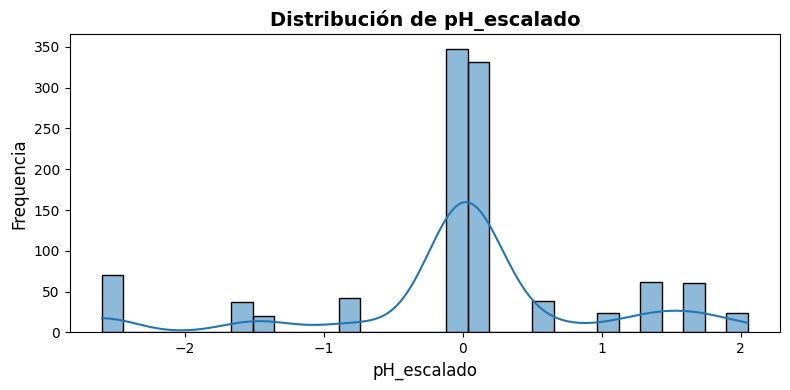

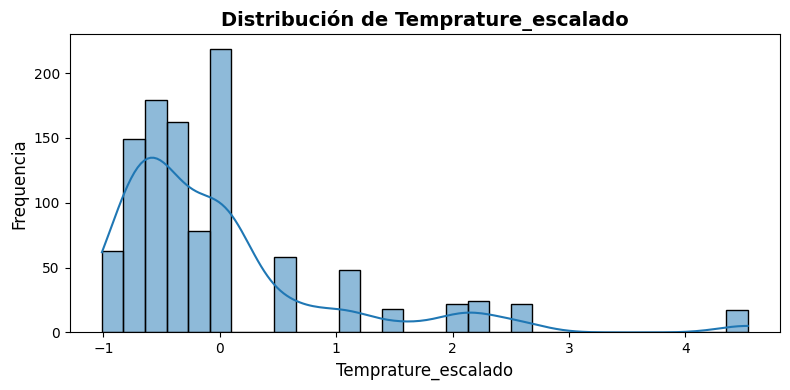

In [12]:
for col in columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df_milk, x=col, kde=True, bins=30)
    plt.title(f'Distribución de {col}', fontsize=14, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequencia', fontsize=12)
    plt.tight_layout()
    plt.show() 

In [13]:
for col in columns:
    plt.figure(figsize=(3, 4))
    sns.boxplot(data=df_milk, y=col)
    plt.title(f'Gráfico de caja de {col}', fontsize=12, fontweight='bold')
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Valor', fontsize=10)
    plt.tight_layout()
    plt.savefig(f"images/cajas/{col.strip()}.png", dpi=150, bbox_inches='tight')
    plt.close()

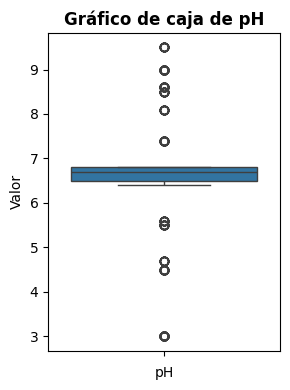

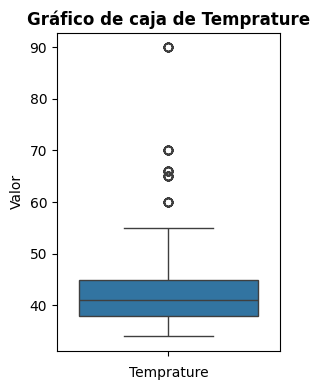

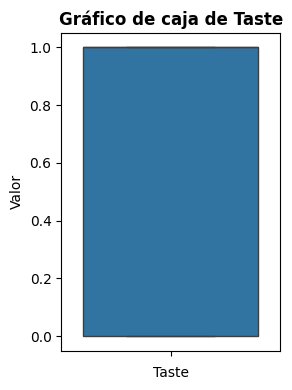

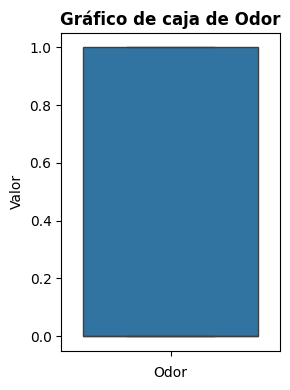

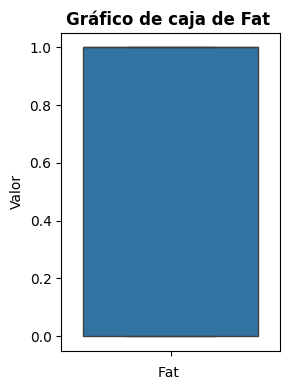

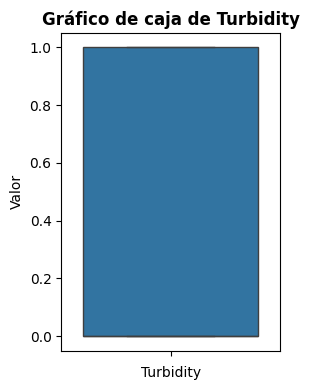

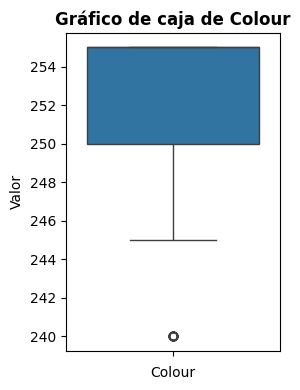

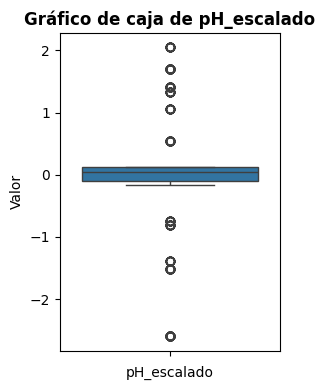

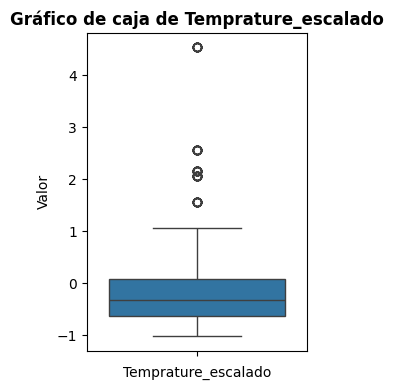

In [14]:
for col in columns:
    plt.figure(figsize=(3, 4))
    sns.boxplot(data=df_milk, y=col)
    plt.title(f'Gráfico de caja de {col}', fontsize=12, fontweight='bold')
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Valor', fontsize=10)
    plt.tight_layout()
    plt.show()

### Análisis de la distribución de la variable objetivo.

In [15]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df_milk, x="Grade", kde=False, bins=30)
plt.title('Distribución Grade', fontsize=14, fontweight='bold')
plt.xlabel("Grade", fontsize=12)
plt.ylabel('Frequencia', fontsize=12)
plt.tight_layout()
plt.savefig("images/histogramas/grade.png", dpi=150, bbox_inches='tight')
plt.close()

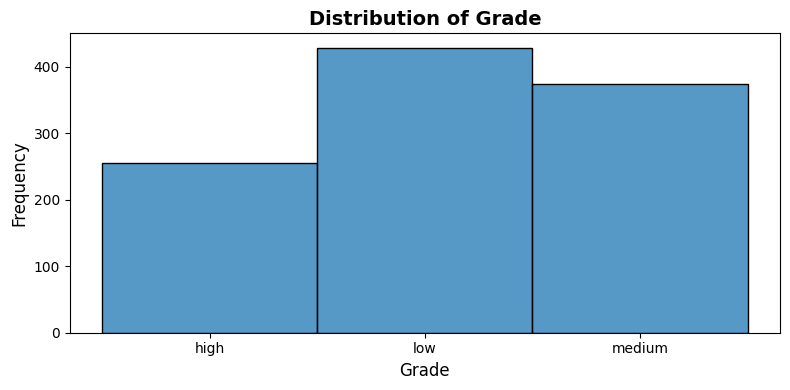

In [16]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df_milk, x="Grade", kde=False, bins=30)
plt.title('Distribution of Grade', fontsize=14, fontweight='bold')
plt.xlabel("Grade", fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

acá podemos observar que las clases estan desbalanceadas y por tanto esto afectará la predicción del modelo de regresión (como veremos más adelante con la leche de calidad 'high')

## 3. Análisis de Correlación

### Cálculo de la matriz de correlación

In [17]:
numeric_df = df_milk[columns].select_dtypes(include='number')


data = numeric_df.values
std = (data - data.mean(axis=0)) / data.std(axis=0)


n = std.shape[0]
corr_matrix = (std.T @ std) / (n - 1)


corr_df = pd.DataFrame(corr_matrix, index=numeric_df.columns, columns=numeric_df.columns)
display(corr_df)

,pH,Temprature,Taste,Odor,Fat,Turbidity,Colour,pH_escalado,Temprature_escalado
pH,1.000945,0.244915,-0.064113,-0.081407,-0.093517,0.048430,-0.164720,1.000945,0.244915
Temprature,0.244915,1.000945,-0.109895,-0.048916,0.024096,0.185281,-0.008519,0.244915,1.000945
Taste,-0.064113,-0.109895,1.000945,0.017599,0.324455,0.055807,-0.082732,-0.064113,-0.109895
Odor,-0.081407,-0.048916,0.017599,1.000945,0.314802,0.458368,-0.039399,-0.081407,-0.048916
Fat,-0.093517,0.024096,0.324455,0.314802,1.000945,0.329575,0.114259,-0.093517,0.024096
Turbidity,0.048430,0.185281,0.055807,0.458368,0.329575,1.000945,0.136565,0.048430,0.185281
Colour,-0.164720,-0.008519,-0.082732,-0.039399,0.114259,0.136565,1.000945,-0.164720,-0.008519
pH_escalado,1.000945,0.244915,-0.064113,-0.081407,-0.093517,0.048430,-0.164720,1.000945,0.244915
Temprature_escalado,0.244915,1.000945,-0.109895,-0.048916,0.024096,0.185281,-0.008519,0.244915,1.000945


In [18]:
corr_df.index = corr_df.index.str.replace('_', r'\_')
corr_df.columns = corr_df.columns.str.replace('_', r'\_')

latex_table = corr_df.to_latex(float_format="%.2f")



latex_table = re.search(r'(\\begin\{tabular\}.*\\end\{tabular\})', latex_table, re.DOTALL).group(1)

with open("tables/correlation_matrix.tex", "w") as f:
    f.write(latex_table)

### Visualización mediante mapa de calor.

In [19]:
matriz_correlacion = df_milk[columns].corr()
plt.figure(figsize=(10,6))
sns.heatmap(matriz_correlacion, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5, cbar=True)
plt.title("Matriz de Correlacción")
plt.savefig("images/correlacion.png", dpi=150, bbox_inches='tight')
plt.close()

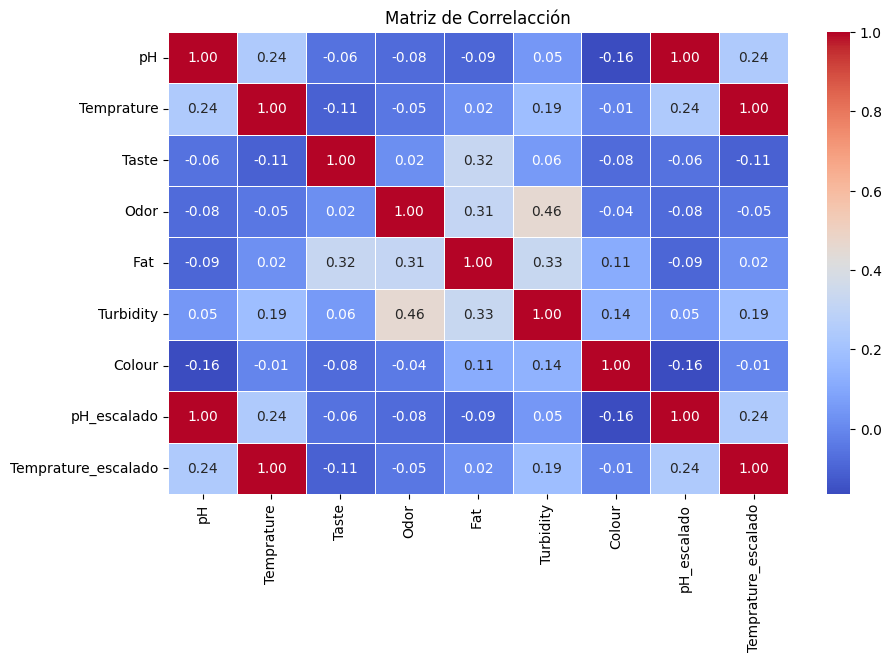

In [20]:
matriz_correlacion = df_milk[columns].corr()
plt.figure(figsize=(10,6))
sns.heatmap(matriz_correlacion, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5, cbar=True)
plt.title("Matriz de Correlacción")
plt.show()

### Interpretación de las relaciones entre variables.

## 4. Implementación del Modelo de Regresión Logística

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


### División del dataset en entrenamiento (80%) y prueba (20%)

In [22]:

X = df_milk[["Temprature_escalado", "pH_escalado", "Taste", "Odor", "Fat ", "Turbidity", "Colour"]]
y = df_milk["Grade_encoded"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Entrenamiento del modelo de regresión logística

In [23]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

c:\Users\kimac\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Evaluación del modelo utilizando
    * Accuracy
    * Matriz de confusión
    * Precision, Recall y F1-Score

In [24]:
y_pred = model.predict(X_test)


metricas_df = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Valor': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average="weighted"),
        recall_score(y_test, y_pred, average="weighted"),
        f1_score(y_test, y_pred, average="weighted")
    ]
}).set_index('Métrica')


display(metricas_df)

,Valor
Métrica,
Accuracy,0.853774
Precision,0.866010
Recall,0.853774
F1-Score,0.856665


In [25]:
latex_table = metricas_df.to_latex(float_format="%.4f")

import re
latex_table = re.search(r'(\\begin\{tabular\}.*\\end\{tabular\})', latex_table, re.DOTALL).group(1)

with open("tables/metrics.tex", "w") as f:
    f.write(latex_table)

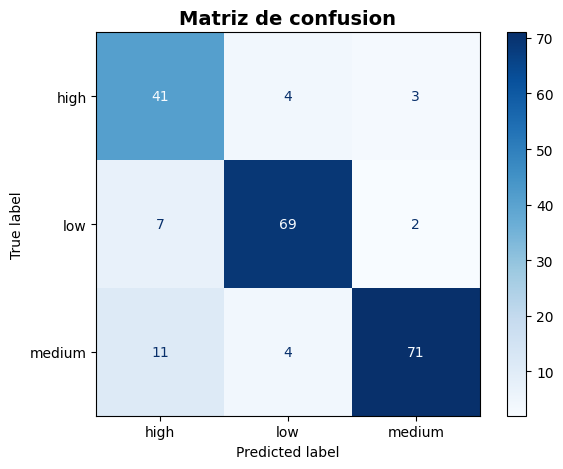

In [26]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues")
plt.title("Matriz de confusion", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [27]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues")
plt.title("Matriz de confusion", fontsize=14, fontweight="bold")
plt.savefig("images/matriz_confusion.png", dpi=150, bbox_inches='tight')
plt.close()

### Interpretación de los coeficientes del modelo

In [28]:
le.classes_

array(['high', 'low', 'medium'], dtype=object)

In [29]:
coef_df = pd.DataFrame(model.coef_, columns=X.columns, index=le.classes_)
coef_df.to_csv("model_coefficients.csv")
print("\nModel Coefficients:")
display(coef_df)


Model Coefficients:


,Temprature_escalado,pH_escalado,Taste,Odor,Fat,Turbidity,Colour
high,-0.875437,0.259468,0.287823,1.937780,3.390067,0.016222,0.089186
low,2.717615,-0.428997,1.880869,0.006123,-0.919736,1.811763,0.250630
medium,-1.842178,0.169529,-2.168692,-1.943903,-2.470331,-1.827984,-0.339816


In [30]:
coef_df.index = coef_df.index.str.replace('_', r'\_')
coef_df.columns = coef_df.columns.str.replace('_', r'\_').str.replace(' ', r'\ ')

latex_table = coef_df.to_latex(float_format="%.4f")
latex_table = re.search(r'(\\begin\{tabular\}.*\\end\{tabular\})', latex_table, re.DOTALL).group(1)

with open("tables/coefficients.tex", "w") as f:
    f.write(latex_table)

### Clase: Alta (Buena)
| Caracteristica | Coeficiente | Interpretación |
|---|---|---|
| Fat | +3.45 | **Caracteristica mas importante** —  la categoria codificada como 1 esta fuertemente asociada con la alta calidad en la leche|
| Odor | +1.96 |  la categoria codificada como 1 esta fuertemente asociada con la alta calidad en la leche|
| Taste | +0.29 | la categoria codificada como 1 tiene un nexo debil con la alta calidad en la leche|
| pH | +0.29 | un ph alto puede tener un leve impacto positivo en la calidad de la leche |
| Turbidity | +0.03 |la categoria codoficada como 1 tiene un enfecto practicamente nulo en la alta calidad de la leche |
| Colour | +0.08 | el color puede no tener impacto en la calidad de la leche  |
| Temperature | **-0.97** | una temperatura alta puede tener un impacto negativo en la calidad de la leche |

---

### Clase: Baja (Mala)
| Caracteristica | Coeficiente | Interpretación |
|---|---|---|
| Temperature | **+2.62** | **Caracteristica importante** — Altas temperaturas indican una mala calidad en la leche |
| Turbidity | +1.80 | la categoria codificada como 1 esta fuertemente asociada con la mala calidad en la leche |
| Taste | +1.75 | la categoria codificada como 1 esta fuertemente asociada con la mala calidad en la leche |
| Odor | -0.10 | Almost no effect |
| Fat | -0.99 | la categoria codificada como 1 está fuertemente asociada con poca probabilidad de mala calidad en la leche |
| Colour | +0.23 | un fuerte color puede tener un impacto leve en la mala calidad de la leche  |
| pH | -0.42 | un ph bajo puede estar levemente asocaida a la mala calidad en la leche |
---

### Clase: Media (Moderada)
| Caracteristica | Coeficiente | Interpretación |
|---|---|---|
| Taste | **-2.04** | la categoria codificada como 1 está fuertemente asociada  en la baja probabilidad de calidad media en la leche |
| Fat | **-2.45** | la categoria codificada como 1 está fuertemente asociada  en la baja probabilidad de calidad media en la leche |
| Odor | **-1.87** | la categoria codificada como 1 está fuertemente asociada  en la baja probabilidad de calidad media en la leche |
| Turbidity | **-1.83** | la categoria codificada como 1 está fuertemente asociada  en la baja probabilidad de calidad media en la leche |
| Temperature | -1.65 | la alta temperatura tiene un impacto negativo en la probabilidad de calidad media en la leche |
| Colour | -0.32 | el color fuerte puede tener un impacto leve en la baja probabilidad de calidad media en al leche |
| pH | 0.13 | el pH puede no tener impacto en la probabilidad de calidad media en la leche |
---

### Resumen

- **Fat y Odor** son las caracteristicas principales para identificar leche de buena calidad.
- **Temperature y Turbidity** son las señales mas fuerte de mala calidad en la leche, temperatura tibia y categoria 1 en la turbidez.
- **Calidad media** esta constatemente vinculada a la ausencia a la ausencia del valor 1 en las categorias Tast, Fat, Odor, Turbidity